# HAM10000 — YOLOv8n-cls + ROI Segmentasyon + Optuna (Colab Pro)

**Bu notebook Colab Pro için uyarlandı.**
- Çıktılar `/content/output_yolov8/` altında, eğitim sonunda **otomatik Drive'a kopyalanır**
- Drive yolu: `/content/drive/MyDrive/cilt_kanseri_ensemble/`
- A100 GPU ile ~30-45 dakika sürer


In [2]:
# ============================================================
# A. GOOGLE DRIVE'I MOUNT ET (sonuçları kalıcı kaydetmek için)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# B. KAGGLE.JSON YÜKLE (HAM10000 indirmek için)
# kaggle.com → profil → Account → Create New API Token ile indirilir
# ============================================================
from google.colab import files
print('Lütfen bilgisayarından kaggle.json dosyasını seç:')
uploaded = files.upload()

Lütfen bilgisayarından kaggle.json dosyasını seç:


Saving kaggle.json to kaggle.json


In [4]:
# ============================================================
# C. HAM10000 DATASET'İ İNDİR
# ============================================================
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

!pip install -q kaggle

print('\n📥 HAM10000 indiriliyor (~5 GB, 1-2 dakika)...')
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000 --unzip

print('\n✅ İndirme tamamlandı!')
print('\nKlasör içeriği:')
!ls /content/ham10000 | head -10


📥 HAM10000 indiriliyor (~5 GB, 1-2 dakika)...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:23<00:00, 236MB/s]


✅ İndirme tamamlandı!

Klasör içeriği:
ham10000_images_part_1
HAM10000_images_part_1
ham10000_images_part_2
HAM10000_images_part_2
HAM10000_metadata.csv
hmnist_28_28_L.csv
hmnist_28_28_RGB.csv
hmnist_8_8_L.csv
hmnist_8_8_RGB.csv


In [5]:
# ============================================================
# D. DATASET DOĞRULAMA
# ============================================================
import os
import pandas as pd

ham_root = '/content/ham10000'
df_check = pd.read_csv(os.path.join(ham_root, 'HAM10000_metadata.csv'))
print(f'Toplam metadata satırı: {len(df_check)}')
print(f'\nSınıf dağılımı:')
print(df_check['dx'].value_counts())

# Görüntü klasörlerini kontrol
for d in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
    full = os.path.join(ham_root, d)
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print(f'  {d}/ -> {n} dosya')

Toplam metadata satırı: 10015

Sınıf dağılımı:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
  HAM10000_images_part_1/ -> 5000 dosya
  HAM10000_images_part_2/ -> 5015 dosya


In [6]:
# ============================================================
# 0. KÜTÜPHANE KURULUMU
# Ultralytics YOLOv8 + Optuna
# ============================================================
!pip install ultralytics optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 44.8 MB/s eta 0:00:00


In [7]:
# ============================================================
# 1. KÜTÜPHANELER
# ============================================================
import os
import shutil
import time
import random
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

from ultralytics import YOLO
import torch
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"Ultralytics ready | PyTorch: {torch.__version__}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics ready | PyTorch: 2.10.0+cu128


In [8]:
# ============================================================
# 2. AYARLAR
# ============================================================
IMG_SIZE   = 224
SEED       = 42
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15

# HAM10000 path'leri (Colab — A,B,C hücrelerinde dataset bu konuma indirilecek)
DATA_DIR     = '/content/ham10000'
METADATA_CSV = os.path.join(DATA_DIR, 'HAM10000_metadata.csv')
IMG_DIR_1    = os.path.join(DATA_DIR, 'HAM10000_images_part_1')
IMG_DIR_2    = os.path.join(DATA_DIR, 'HAM10000_images_part_2')

# Çıktı path'leri (Colab local /content + Drive yedek)
OUTPUT_DIR     = '/content/output_yolov8'
DRIVE_OUTPUT   = '/content/drive/MyDrive/cilt_kanseri_ensemble'  # kalıcı yedek
ROI_CACHE_DIR  = os.path.join(OUTPUT_DIR, 'roi_cache')
YOLO_DATA_DIR  = os.path.join(OUTPUT_DIR, 'ham10000_yolo')  # YOLOv8 klasör yapısı
RUNS_DIR       = os.path.join(OUTPUT_DIR, 'runs')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

# Kayıt yolları (output klasörüne yaz, en sonda Drive'a kopyala)
MODEL_SAVE_PATH  = os.path.join(OUTPUT_DIR, 'best_yolov8n_cls.pt')
PROBS_SAVE_PATH  = os.path.join(OUTPUT_DIR, 'probabilities_yolov8n_cls.npy')
LABELS_SAVE_PATH = os.path.join(OUTPUT_DIR, 'test_labels_yolov8n_cls.npy')
CM_SAVE_PATH     = os.path.join(OUTPUT_DIR, 'confusion_matrix_yolov8n_cls.jpg')
STUDY_SAVE_PATH  = os.path.join(OUTPUT_DIR, 'optuna_study_yolov8.pkl')

# 7 sınıf (HAM10000)
TARGET_CLASSES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_FULL_NAMES = {
    'akiec': 'Actinic Keratoses',
    'bcc':   'Basal Cell Carcinoma',
    'bkl':   'Benign Keratosis',
    'df':    'Dermatofibroma',
    'mel':   'Melanoma',
    'nv':    'Melanocytic Nevi',
    'vasc':  'Vascular Lesions'
}

# Optuna kısıtlama (hocanın isteği)
OPTUNA_N_TRIALS = 15
OPTUNA_EPOCHS   = 6

# Final eğitim
FINAL_EPOCHS = 50
PATIENCE     = 12

print(f'IMG_SIZE: {IMG_SIZE}')
print(f'Sınıf sayısı: {len(TARGET_CLASSES)}')
print(f'Optuna: {OPTUNA_N_TRIALS} trial × {OPTUNA_EPOCHS} epoch')
print(f'Final: {FINAL_EPOCHS} epoch (early stopping patience={PATIENCE})')
print(f'Çıktı dizini: {OUTPUT_DIR}')
print(f'Drive yedek : {DRIVE_OUTPUT}')


IMG_SIZE: 224
Sınıf sayısı: 7
Optuna: 15 trial × 6 epoch
Final: 50 epoch (early stopping patience=12)
Çıktı dizini: /content/output_yolov8
Drive yedek : /content/drive/MyDrive/cilt_kanseri_ensemble


In [9]:
# ============================================================
# 3. SEED + DEVICE
# ============================================================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    print(f"Kullanılan cihaz: CUDA - {torch.cuda.get_device_name(0)}")
    free, total = torch.cuda.mem_get_info(0)
    print(f"VRAM: {total / 1024**3:.1f} GB")
    DEVICE = 0  # YOLOv8 device parametresi int olarak GPU index
else:
    print("⚠️ CUDA bulunamadı! CPU kullanılacak.")
    DEVICE = 'cpu'

Kullanılan cihaz: CUDA - NVIDIA A100-SXM4-40GB
VRAM: 39.5 GB


In [10]:
# ============================================================
# 4. METADATA YÜKLEME + IMAGE PATH EŞLEME
# ============================================================
df = pd.read_csv(METADATA_CSV)
print(f"Metadata satır sayısı: {len(df)}")

# Her image_id için tam path bul
all_images = {}
for img_dir in [IMG_DIR_1, IMG_DIR_2]:
    if os.path.exists(img_dir):
        for fname in os.listdir(img_dir):
            if fname.lower().endswith('.jpg'):
                image_id = fname.replace('.jpg', '')
                all_images[image_id] = os.path.join(img_dir, fname)

df['image_path'] = df['image_id'].map(all_images)
df = df.dropna(subset=['image_path']).reset_index(drop=True)

class_to_idx = {cls: idx for idx, cls in enumerate(TARGET_CLASSES)}
df['label'] = df['dx'].map(class_to_idx)

print(f"Final satır sayısı: {len(df)}")
print(f"\nSınıf dağılımı:")
for cls in TARGET_CLASSES:
    n = (df['dx'] == cls).sum()
    print(f"  {cls} ({CLASS_FULL_NAMES[cls]}): {n}")

Metadata satır sayısı: 10015
Final satır sayısı: 10015

Sınıf dağılımı:
  akiec (Actinic Keratoses): 327
  bcc (Basal Cell Carcinoma): 514
  bkl (Benign Keratosis): 1099
  df (Dermatofibroma): 115
  mel (Melanoma): 1113
  nv (Melanocytic Nevi): 6705
  vasc (Vascular Lesions): 142


In [11]:
# ============================================================
# 5. TRAIN / VAL / TEST SPLIT (lesion-based, stratified)
# EfficientNet ile aynı split mantığı: data leakage önleme
# ============================================================
lesion_df = df.groupby('lesion_id').first().reset_index()[['lesion_id', 'dx']]

trainval_lesions, test_lesions = train_test_split(
    lesion_df, test_size=TEST_SPLIT, stratify=lesion_df['dx'], random_state=SEED
)
val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
train_lesions, val_lesions = train_test_split(
    trainval_lesions, test_size=val_ratio, stratify=trainval_lesions['dx'], random_state=SEED
)

train_df = df[df['lesion_id'].isin(train_lesions['lesion_id'])].reset_index(drop=True)
val_df   = df[df['lesion_id'].isin(val_lesions['lesion_id'])].reset_index(drop=True)
test_df  = df[df['lesion_id'].isin(test_lesions['lesion_id'])].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 7054 | Val: 1464 | Test: 1497


In [12]:
# ============================================================
# 6. ROI (REGION OF INTEREST) FONKSİYONU
# EfficientNet ile aynı: Otsu + morfoloji + contour + bbox
# ============================================================
def extract_roi(image_path, target_size=224):
    img = cv2.imread(image_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (11, 11), 0)

    _, thresh = cv2.threshold(
        blurred, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        img_area = img.shape[0] * img.shape[1]

        if area < img_area * 0.01 or area > img_area * 0.95:
            roi = img_rgb
        else:
            x, y, w, h = cv2.boundingRect(largest)
            pad_x = int(w * 0.15)
            pad_y = int(h * 0.15)
            x1 = max(0, x - pad_x)
            y1 = max(0, y - pad_y)
            x2 = min(img.shape[1], x + w + pad_x)
            y2 = min(img.shape[0], y + h + pad_y)
            roi = img_rgb[y1:y2, x1:x2]
    else:
        roi = img_rgb

    roi = cv2.resize(roi, (target_size, target_size))
    return roi

In [13]:
# ============================================================
# 7. ROI'LERİ YOLOV8 KLASÖR YAPISINA YAZMA
# YOLOv8 classification şu yapıyı bekliyor:
#   ham10000_yolo/
#     train/
#       akiec/   bcc/   bkl/   df/   mel/   nv/   vasc/
#     val/
#       akiec/   bcc/   ...
#     test/
#       akiec/   bcc/   ...
# Her görüntünün ROI'sini hesaplayıp ilgili klasöre .jpg olarak kaydediyoruz.
# ============================================================
def setup_yolo_dataset(target_dir, splits_dict):
    """
    splits_dict: {'train': train_df, 'val': val_df, 'test': test_df}
    """
    # Önceki çalıştırmada varsa temizle
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)

    # Klasör yapısı oluştur
    for split_name in splits_dict.keys():
        for cls in TARGET_CLASSES:
            Path(target_dir, split_name, cls).mkdir(parents=True, exist_ok=True)

    # ROI'leri hesapla ve kaydet
    total_count = 0
    fail_count = 0
    start = time.time()

    for split_name, split_df in splits_dict.items():
        for idx, row in split_df.iterrows():
            img_path = row['image_path']
            cls = row['dx']
            image_id = row['image_id']

            roi = extract_roi(img_path, IMG_SIZE)
            if roi is None:
                fail_count += 1
                continue

            # BGR olarak kaydet (cv2.imwrite)
            out_path = os.path.join(target_dir, split_name, cls, f"{image_id}.jpg")
            cv2.imwrite(out_path, cv2.cvtColor(roi, cv2.COLOR_RGB2BGR))
            total_count += 1

            if total_count % 1000 == 0:
                elapsed = time.time() - start
                print(f"  {total_count} görüntü işlendi - {elapsed:.1f}s")

    elapsed = time.time() - start
    print(f"\nTamamlandı: {total_count} görüntü | Hata: {fail_count} | Süre: {elapsed/60:.1f} dk")

splits_dict = {'train': train_df, 'val': val_df, 'test': test_df}
print("YOLOv8 dataset yapısı oluşturuluyor (ROI'ler ile)...")
setup_yolo_dataset(YOLO_DATA_DIR, splits_dict)

# Doğrulama: her klasörde kaç dosya var?
print("\n📊 Klasör içerikleri:")
for split in ['train', 'val', 'test']:
    print(f"\n{split}/")
    for cls in TARGET_CLASSES:
        cls_dir = os.path.join(YOLO_DATA_DIR, split, cls)
        n = len(os.listdir(cls_dir))
        print(f"  {cls}: {n}")

YOLOv8 dataset yapısı oluşturuluyor (ROI'ler ile)...
  1000 görüntü işlendi - 8.9s
  2000 görüntü işlendi - 17.3s
  3000 görüntü işlendi - 26.3s
  4000 görüntü işlendi - 34.9s
  5000 görüntü işlendi - 43.3s
  6000 görüntü işlendi - 51.6s
  7000 görüntü işlendi - 59.9s
  8000 görüntü işlendi - 68.5s
  9000 görüntü işlendi - 76.9s
  10000 görüntü işlendi - 85.3s

Tamamlandı: 10015 görüntü | Hata: 0 | Süre: 1.4 dk

📊 Klasör içerikleri:

train/
  akiec: 233
  bcc: 365
  bkl: 775
  df: 76
  mel: 777
  nv: 4730
  vasc: 98

val/
  akiec: 43
  bcc: 72
  bkl: 167
  df: 17
  mel: 168
  nv: 975
  vasc: 22

test/
  akiec: 51
  bcc: 77
  bkl: 157
  df: 22
  mel: 168
  nv: 1000
  vasc: 22


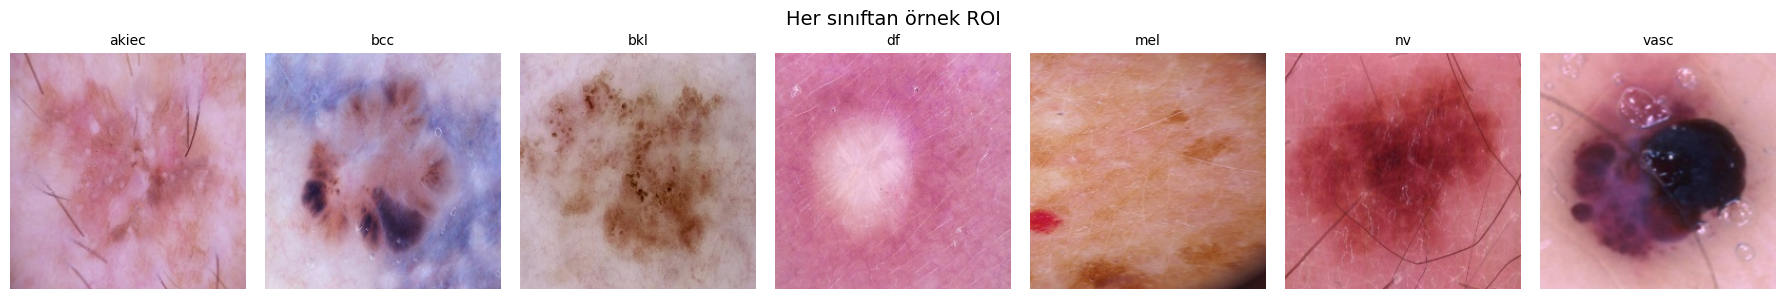

In [14]:
# ============================================================
# 8. ROI ÖRNEKLERİNİ GÖRSELLEŞTİR
# ============================================================
fig, axes = plt.subplots(1, 7, figsize=(18, 3))
fig.suptitle('Her sınıftan örnek ROI', fontsize=14)

for col, cls in enumerate(TARGET_CLASSES):
    cls_dir = os.path.join(YOLO_DATA_DIR, 'train', cls)
    sample_file = os.listdir(cls_dir)[0]
    img = cv2.imread(os.path.join(cls_dir, sample_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[col].imshow(img)
    axes[col].set_title(f"{cls}", fontsize=10)
    axes[col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'yolo_roi_examples.png'), dpi=100, bbox_inches='tight')
plt.show()

In [15]:
# ============================================================
# 9. OPTUNA OBJECTIVE FONKSİYONU
# EfficientNet ile AYNI search space VE AYNI metrik (macro F1).
# 4 parametre: lr, dropout, weight_decay, batch_size
# Hocanın isteği: KISITLI search space.
# ============================================================
def objective(trial):
    # KISITLI search space — EfficientNet ile birebir aynı
    lr           = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    dropout      = trial.suggest_float('dropout', 0.2, 0.5)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [32, 64])

    model = YOLO('yolov8n-cls.pt')

    try:
        results = model.train(
            data=YOLO_DATA_DIR,
            epochs=OPTUNA_EPOCHS,
            imgsz=IMG_SIZE,
            batch=batch_size,
            lr0=lr,
            lrf=0.01,
            weight_decay=weight_decay,
            dropout=dropout,
            device=DEVICE,
            project=RUNS_DIR,
            name=f'optuna_trial_{trial.number}',
            verbose=False,
            plots=False,
            save=True,        # Best.pt lazım, F1 hesaplayacağız
            patience=0,
            seed=SEED,
            exist_ok=True
        )

        # Val set üzerinde best.pt ile tahmin yap, macro F1 hesapla
        best_pt = os.path.join(RUNS_DIR, f'optuna_trial_{trial.number}', 'weights', 'best.pt')
        eval_model = YOLO(best_pt)

        val_root = os.path.join(YOLO_DATA_DIR, 'val')
        y_true_val = []
        y_pred_val = []
        for cls_idx, cls in enumerate(TARGET_CLASSES):
            cls_dir = os.path.join(val_root, cls)
            files = sorted(os.listdir(cls_dir))
            paths = [os.path.join(cls_dir, f) for f in files]
            preds = eval_model(paths, imgsz=IMG_SIZE, device=DEVICE, verbose=False)
            for r in preds:
                pred = int(np.argmax(r.probs.data.cpu().numpy()))
                y_true_val.append(cls_idx)
                y_pred_val.append(pred)

        _, _, val_f1, _ = precision_recall_fscore_support(
            y_true_val, y_pred_val, average='macro', zero_division=0
        )

        del eval_model
    except Exception as e:
        print(f"Trial {trial.number} hata: {e}")
        val_f1 = 0.0

    del model
    torch.cuda.empty_cache()

    return val_f1

In [16]:
# ============================================================
# 10. OPTUNA STUDY ÇALIŞTIR
# ============================================================
print("=" * 60)
print(f"OPTUNA HİPERPARAMETRE OPTİMİZASYONU - YOLOv8n-cls")
print(f"Trial: {OPTUNA_N_TRIALS} | Epoch/trial: {OPTUNA_EPOCHS}")
print(f"Metrik: Val Macro F1 (EfficientNet ile tutarlı)")
print("=" * 60)

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=2)
)

study_start = time.time()
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=True)
study_elapsed = (time.time() - study_start) / 60

print(f"\nOptuna tamamlandı! Süre: {study_elapsed:.1f} dakika")
print(f"\nEn iyi trial:")
print(f"  Val F1: {study.best_value:.4f}")
print(f"  Parametreler:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

OPTUNA HİPERPARAMETRE OPTİMİZASYONU - YOLOv8n-cls
Trial: 15 | Epoch/trial: 6
Metrik: Val Macro F1 (EfficientNet ile tutarlı)


  0%|          | 0/15 [00:00<?, ?it/s]

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/output_yolov8/ham10000_yolo, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.4852142919229748, dynamic=False, embed=None, end2end=None, epochs=6, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003574712922600243, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=optuna_trial_0, nbs=64, nms=False, opset=None, opti

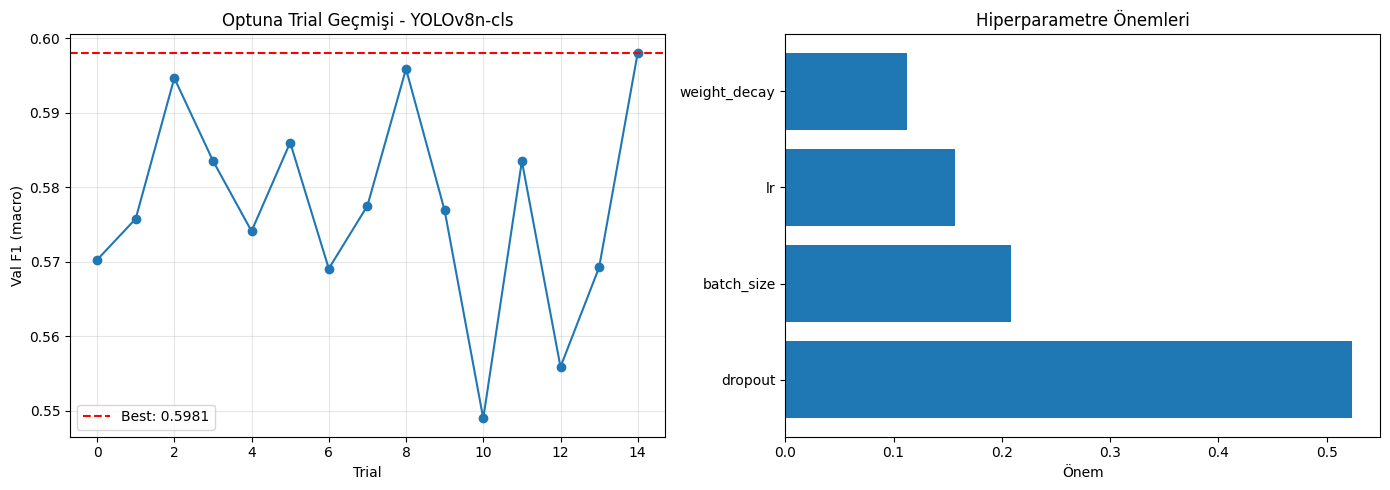

In [17]:
# ============================================================
# 11. OPTUNA SONUÇLARINI GÖRSELLEŞTİR + KAYDET
# ============================================================
import pickle
with open(STUDY_SAVE_PATH, 'wb') as f:
    pickle.dump(study, f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trials_df = study.trials_dataframe()
completed = trials_df[trials_df['state'] == 'COMPLETE']
axes[0].plot(completed['number'], completed['value'], 'o-')
axes[0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val F1 (macro)')
axes[0].set_title('Optuna Trial Geçmişi - YOLOv8n-cls')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()))
    axes[1].set_xlabel('Önem')
    axes[1].set_title('Hiperparametre Önemleri')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Hesaplanamadı: {e}', ha='center', va='center')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'optuna_results_yolov8.png'), dpi=100, bbox_inches='tight')
plt.show()

In [18]:
# ============================================================
# 12. EN İYİ PARAMETRELERLE FİNAL EĞİTİM
# Optuna'nın bulduğu en iyi paramlarla, full epoch sayısıyla
# Erken durdurma (patience=12) ile aşırı eğitimi engelliyoruz
# ============================================================
best_params = study.best_params
BEST_LR     = best_params['lr']
BEST_DROP   = best_params['dropout']
BEST_WD     = best_params['weight_decay']
BEST_BS     = best_params['batch_size']

print("=" * 60)
print("FİNAL EĞİTİM - YOLOv8n-cls")
print(f"LR={BEST_LR:.5f} | Dropout={BEST_DROP:.3f} | WD={BEST_WD:.5f} | BS={BEST_BS}")
print("=" * 60)

final_model = YOLO('yolov8n-cls.pt')

final_start = time.time()

results = final_model.train(
    data=YOLO_DATA_DIR,
    epochs=FINAL_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BEST_BS,
    lr0=BEST_LR,
    lrf=0.01,
    weight_decay=BEST_WD,
    dropout=BEST_DROP,
    device=DEVICE,
    project=RUNS_DIR,
    name='final_yolov8_cls',
    patience=PATIENCE,
    save=True,
    seed=SEED,
    exist_ok=True,
    plots=True,
    verbose=True
)

final_elapsed = (time.time() - final_start) / 60
print(f"\nFinal eğitim süresi: {final_elapsed:.1f} dakika")

# En iyi modeli kopyala
best_pt_src = os.path.join(RUNS_DIR, 'final_yolov8_cls', 'weights', 'best.pt')
if os.path.exists(best_pt_src):
    shutil.copy(best_pt_src, MODEL_SAVE_PATH)
    print(f"Model kaydedildi: {MODEL_SAVE_PATH}")

FİNAL EĞİTİM - YOLOv8n-cls
LR=0.00032 | Dropout=0.349 | WD=0.00027 | BS=32
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/output_yolov8/ham10000_yolo, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.349142798918516, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00032259759297193033, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.

In [19]:
# ============================================================
# 13. TEST DEĞERLENDİRMESİ
# YOLOv8 default olarak val klasörü değerlendiriyor.
# Test için manuel değerlendirme yapacağız.
# ============================================================
best_model = YOLO(MODEL_SAVE_PATH)

# Test set üzerinde tahminleri topla
y_true = []
y_pred = []
y_probs = []

test_root = os.path.join(YOLO_DATA_DIR, 'test')

print("Test set tahminleri yapılıyor...")
for cls_idx, cls in enumerate(TARGET_CLASSES):
    cls_dir = os.path.join(test_root, cls)
    files = sorted(os.listdir(cls_dir))
    paths = [os.path.join(cls_dir, f) for f in files]

    # Batch tahmin (hızlı)
    results = best_model(paths, imgsz=IMG_SIZE, device=DEVICE, verbose=False)

    for r in results:
        probs = r.probs.data.cpu().numpy()  # softmax probabilities
        pred = int(np.argmax(probs))

        # YOLOv8 sınıf sıralamasını TARGET_CLASSES sırasına eşle
        # YOLOv8 alfabetik sıralıyor; bizim TARGET_CLASSES da alfabetik (akiec, bcc, bkl, df, mel, nv, vasc)
        # Yani aynı, ama emin olmak için kontrol edelim
        y_true.append(cls_idx)
        y_pred.append(pred)
        y_probs.append(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# YOLOv8 model.names ile alfabetik sıralamayı doğrulayalım
yolo_class_names = [best_model.names[i] for i in range(len(best_model.names))]
print(f"\nYOLOv8 sınıf sırası: {yolo_class_names}")
print(f"Bizim sıramız:        {TARGET_CLASSES}")
assert yolo_class_names == TARGET_CLASSES, "⚠️ Sınıf sırası uyumsuz!"
print("✅ Sınıf sıraları uyumlu")

Test set tahminleri yapılıyor...

YOLOv8 sınıf sırası: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Bizim sıramız:        ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
✅ Sınıf sıraları uyumlu


In [20]:
# ============================================================
# 14. METRİKLER
# ============================================================
test_acc = (y_pred == y_true).mean()
test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
test_prec_w, test_rec_w, test_f1_w, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

print("=" * 60)
print("FİNAL TEST SONUÇLARI - YOLOv8n-cls + ROI + Optuna")
print("=" * 60)
print(f"Test Accuracy            : {test_acc:.4f}")
print(f"Test Precision (macro)   : {test_prec:.4f}")
print(f"Test Recall    (macro)   : {test_rec:.4f}")
print(f"Test F1        (macro)   : {test_f1:.4f}")
print(f"Test F1        (weighted): {test_f1_w:.4f}")

if torch.cuda.is_available():
    print(f"\nMax VRAM kullanımı: {torch.cuda.max_memory_allocated()/1024**2:.0f} MB")

FİNAL TEST SONUÇLARI - YOLOv8n-cls + ROI + Optuna
Test Accuracy            : 0.8029
Test Precision (macro)   : 0.6840
Test Recall    (macro)   : 0.5488
Test F1        (macro)   : 0.5930
Test F1        (weighted): 0.7970

Max VRAM kullanımı: 2971 MB


In [21]:
# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=TARGET_CLASSES,
    digits=3, zero_division=0
))


Classification Report:
              precision    recall  f1-score   support

       akiec      0.522     0.235     0.324        51
         bcc      0.759     0.532     0.626        77
         bkl      0.565     0.694     0.623       157
          df      0.545     0.273     0.364        22
         mel      0.571     0.595     0.583       168
          nv      0.897     0.921     0.909      1000
        vasc      0.929     0.591     0.722        22

    accuracy                          0.803      1497
   macro avg      0.684     0.549     0.593      1497
weighted avg      0.801     0.803     0.797      1497



In [22]:
# ============================================================
# 16. NPY DOSYALARINI KAYDET (Ensemble için lazım olacak)
# ============================================================
np.save(PROBS_SAVE_PATH, y_probs)
np.save(LABELS_SAVE_PATH, y_true)
print(f"Probabilities: {PROBS_SAVE_PATH} | shape: {y_probs.shape}")
print(f"Labels:        {LABELS_SAVE_PATH} | shape: {y_true.shape}")

Probabilities: /content/output_yolov8/probabilities_yolov8n_cls.npy | shape: (1497, 7)
Labels:        /content/output_yolov8/test_labels_yolov8n_cls.npy | shape: (1497,)


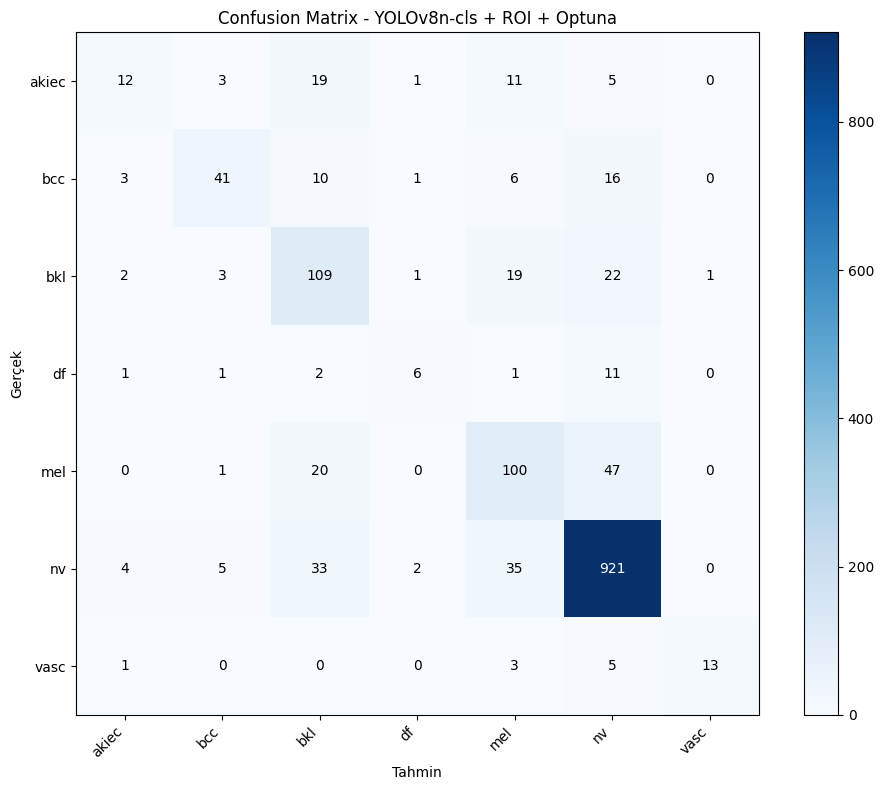

Kaydedildi: /content/output_yolov8/confusion_matrix_yolov8n_cls.jpg


In [23]:
# ============================================================
# 17. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)
NUM_CLASSES = len(TARGET_CLASSES)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - YOLOv8n-cls + ROI + Optuna')
plt.colorbar()

plt.xticks(range(NUM_CLASSES), TARGET_CLASSES, rotation=45, ha='right', fontsize=10)
plt.yticks(range(NUM_CLASSES), TARGET_CLASSES, fontsize=10)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=10)

plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.savefig(CM_SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Kaydedildi: {CM_SAVE_PATH}")

In [24]:
# ============================================================
# 18. ÖZET
# ============================================================
print("=" * 60)
print("PROJE TAMAMLANDI - YOLOv8n-cls")
print("=" * 60)
print(f"Model: YOLOv8n-cls (Ultralytics)")
print(f"Pipeline: ROI Segmentasyon + Optuna HPO")
print(f"Sınıf sayısı: {NUM_CLASSES}")
print(f"\nOptuna en iyi parametreler:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nFinal Test Accuracy : {test_acc:.4f}")
print(f"Final Test F1 (macro): {test_f1:.4f}")
print(f"\nKaydedilen dosyalar:")
print(f"  Model       : {MODEL_SAVE_PATH}")
print(f"  Probs       : {PROBS_SAVE_PATH}")
print(f"  Labels      : {LABELS_SAVE_PATH}")
print(f"  CM          : {CM_SAVE_PATH}")
print(f"  Optuna study: {STUDY_SAVE_PATH}")

PROJE TAMAMLANDI - YOLOv8n-cls
Model: YOLOv8n-cls (Ultralytics)
Pipeline: ROI Segmentasyon + Optuna HPO
Sınıf sayısı: 7

Optuna en iyi parametreler:
  lr: 0.00032259759297193033
  dropout: 0.349142798918516
  weight_decay: 0.0002689350603616123
  batch_size: 32

Final Test Accuracy : 0.8029
Final Test F1 (macro): 0.5930

Kaydedilen dosyalar:
  Model       : /content/output_yolov8/best_yolov8n_cls.pt
  Probs       : /content/output_yolov8/probabilities_yolov8n_cls.npy
  Labels      : /content/output_yolov8/test_labels_yolov8n_cls.npy
  CM          : /content/output_yolov8/confusion_matrix_yolov8n_cls.jpg
  Optuna study: /content/output_yolov8/optuna_study_yolov8.pkl


In [25]:
# ============================================================
# 19. DRIVE'A YEDEKLEME (KRİTİK — session ölmeden önce!)
# Tüm önemli dosyaları /content/drive/MyDrive/cilt_kanseri_ensemble/
# klasörüne kopyala. Session ölse bile dosyalar Drive'da kalır.
# ============================================================
import shutil

files_to_backup = [
    PROBS_SAVE_PATH,
    LABELS_SAVE_PATH,
    MODEL_SAVE_PATH,
    CM_SAVE_PATH,
    STUDY_SAVE_PATH,
]

print('Drive\'a yedekleniyor...')
for src in files_to_backup:
    if os.path.exists(src):
        dst = os.path.join(DRIVE_OUTPUT, os.path.basename(src))
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1024 / 1024
        print(f'  ✓ {os.path.basename(src)} ({size_mb:.2f} MB)')
    else:
        print(f'  ✗ BULUNAMADI: {src}')

print(f'\nDrive klasörü: {DRIVE_OUTPUT}')
print('\nİçindekiler:')
for f in sorted(os.listdir(DRIVE_OUTPUT)):
    full = os.path.join(DRIVE_OUTPUT, f)
    if os.path.isfile(full):
        size_mb = os.path.getsize(full) / 1024 / 1024
        print(f'  {f} ({size_mb:.2f} MB)')

print('\n🎉 Yedekleme tamamlandı! Artık session ölse bile dosyalar Drive\'da güvende.')

Drive'a yedekleniyor...
  ✓ probabilities_yolov8n_cls.npy (0.04 MB)
  ✓ test_labels_yolov8n_cls.npy (0.01 MB)
  ✓ best_yolov8n_cls.pt (2.84 MB)
  ✓ confusion_matrix_yolov8n_cls.jpg (0.07 MB)
  ✓ optuna_study_yolov8.pkl (0.02 MB)

Drive klasörü: /content/drive/MyDrive/cilt_kanseri_ensemble

İçindekiler:
  best_yolov8n_cls.pt (2.84 MB)
  confusion_matrix_yolov8n_cls.jpg (0.07 MB)
  optuna_study_yolov8.pkl (0.02 MB)
  probabilities_yolov8n_cls.npy (0.04 MB)
  test_labels_yolov8n_cls.npy (0.01 MB)

🎉 Yedekleme tamamlandı! Artık session ölse bile dosyalar Drive'da güvende.
